# CityFlo Bus Service — Metro Cities: Data Analysis

**Dataset:** `cityflo_bus_service_metro_cities_clean.csv`

This notebook performs exploratory and statistical analysis on the cleaned CityFlo bus service dataset.

The analysis focuses on trip demand, revenue, operational performance, delays, cancellations, occupancy, customer experience, booking behavior, and payment patterns.

The analysis includes:
1. Data Verification
2. Univariate Analysis
3. Bivariate Analysis
4. Multivariate Analysis
5. Hypothesis Testing
6. KPI Analysis
7. Dashboard Supporting Analysis
8. Conclusion

## **1. Environment Setup**

In [1]:
# Load essential libraries for Data Handling (pandas, numpy), Plotting (matplotlib, seaborn), and Statistics (scipy)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display plots directly inside the notebook
%matplotlib inline

# Set a default visual style for charts
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 50)

## **2. Load the Cleaned Dataset**

In [2]:
# Mount Google Drive to access the dataset stored in Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [64]:
# Load the raw dataset into a Pandas DataFrame
CLEANED_PATH = "/content/drive/MyDrive/cityflo_bus_service_metro_cities_cleaned.csv"
df = pd.read_csv(CLEANED_PATH)

# Display top 5 rows to verify data is loaded correctly
df.head()

,trip_id,customer_id,gender,age,city,route_id,route_name,origin_stop,destination_stop,bus_type,trip_date,scheduled_departure,actual_departure,scheduled_arrival,actual_arrival,distance_km,fare_inr,discount_inr,payment_mode,booking_channel,trip_status,cancellation_reason,rating,occupancy_pct,weather,is_peak_hour,subscription_type,gps_enabled,complaint_raised,trip_year,trip_month,trip_weekday,delay_minutes,is_delayed,net_revenue_inr,age_group
0,TRP000768,CUST01278,Female,21.0,Mumbai,RTMU005,Lower Parel - Mulund,Lower Parel,Mulund,AC Sleeper,2024-09-21,20:25,20:25,20:58,20:58,10.9,153.0,0.0,UPI,Corporate Portal,Completed,NaN,5.0,84.6,Haze,False,Corporate Plan,True,False,2024,9,Saturday,0.0,False,153.0,18-25
1,TRP002439,CUST01290,Male,24.0,Hyderabad,RTHY038,HITEC City - Kondapur,HITEC City,Kondapur,AC Seater,2024-08-08,14:50,15:12,15:29,15:51,14.1,127.0,0.0,Debit Card,Kiosk,Delayed-Completed,NaN,NaN,28.3,Heavy Rain,False,Weekly Pass,True,False,2024,8,Thursday,22.0,True,127.0,18-25
2,TRP000793,CUST01285,Female,18.0,Pune,RTPU012,Aundh - Magarpatta,Aundh,Magarpatta,AC Seater,2024-03-19,08:15,08:15,09:42,09:42,27.6,234.0,19.0,Cash,Corporate Portal,Completed,NaN,3.0,15.4,Cloudy,True,Single Ride,True,False,2024,3,Tuesday,0.0,False,215.0,18-25
3,TRP002802,CUST00625,Female,23.0,Mumbai,RTMU010,Ghatkopar - Lower Parel,Ghatkopar,Lower Parel,AC Sleeper,2024-12-29,17:45,17:45,18:57,NaN,28.6,310.0,0.0,Debit Card,Corporate Portal,No-show,Customer Request,NaN,68.1,Clear,False,Corporate Plan,True,True,2024,12,Sunday,0.0,False,310.0,18-25
4,TRP001653,CUST00276,Female,20.0,Bangalore,RTBA024,Hebbal - Electronic City,Hebbal,Electronic City,AC Seater,2024-05-15,13:00,13:40,13:35,14:15,17.8,202.0,0.0,UPI,Corporate Portal,Delayed-Completed,NaN,NaN,23.7,Haze,False,Corporate Plan,True,False,2024,5,Wednesday,40.0,True,202.0,18-25


## **3. Data Verification**

Before starting the analysis, the cleaned dataset is checked to confirm its shape, date format, data types, and remaining missing values.

In [4]:
df["trip_date"] = pd.to_datetime(
    df["trip_date"],
    errors="coerce"
)

print("trip_date datatype:", df["trip_date"].dtype)
df[["trip_date"]].head()

trip_date datatype: datetime64[ns]


,trip_date
0,2024-09-21
1,2024-08-08
2,2024-03-19
3,2024-12-29
4,2024-05-15


Check the final dataset shape, column names, data types, and remaining missing values before starting the analysis.

In [5]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (3200, 36)

Column Names:
['trip_id', 'customer_id', 'gender', 'age', 'city', 'route_id', 'route_name', 'origin_stop', 'destination_stop', 'bus_type', 'trip_date', 'scheduled_departure', 'actual_departure', 'scheduled_arrival', 'actual_arrival', 'distance_km', 'fare_inr', 'discount_inr', 'payment_mode', 'booking_channel', 'trip_status', 'cancellation_reason', 'rating', 'occupancy_pct', 'weather', 'is_peak_hour', 'subscription_type', 'gps_enabled', 'complaint_raised', 'trip_year', 'trip_month', 'trip_weekday', 'delay_minutes', 'is_delayed', 'net_revenue_inr', 'age_group']

Data Types:
trip_id                        object
customer_id                    object
gender                         object
age                           float64
city                           object
route_id                       object
route_name                     object
origin_stop                    object
destination_stop               object
bus_type                       object
trip_date     

## **4. Univariate Analysis**

**Numerical:** histogram, box plot, summary stats (mean, median, mode, std, skew, kurtosis).

**Categorical:** `value_counts()`, bar chart, pie chart.

**4.1 Numerical Distribution**

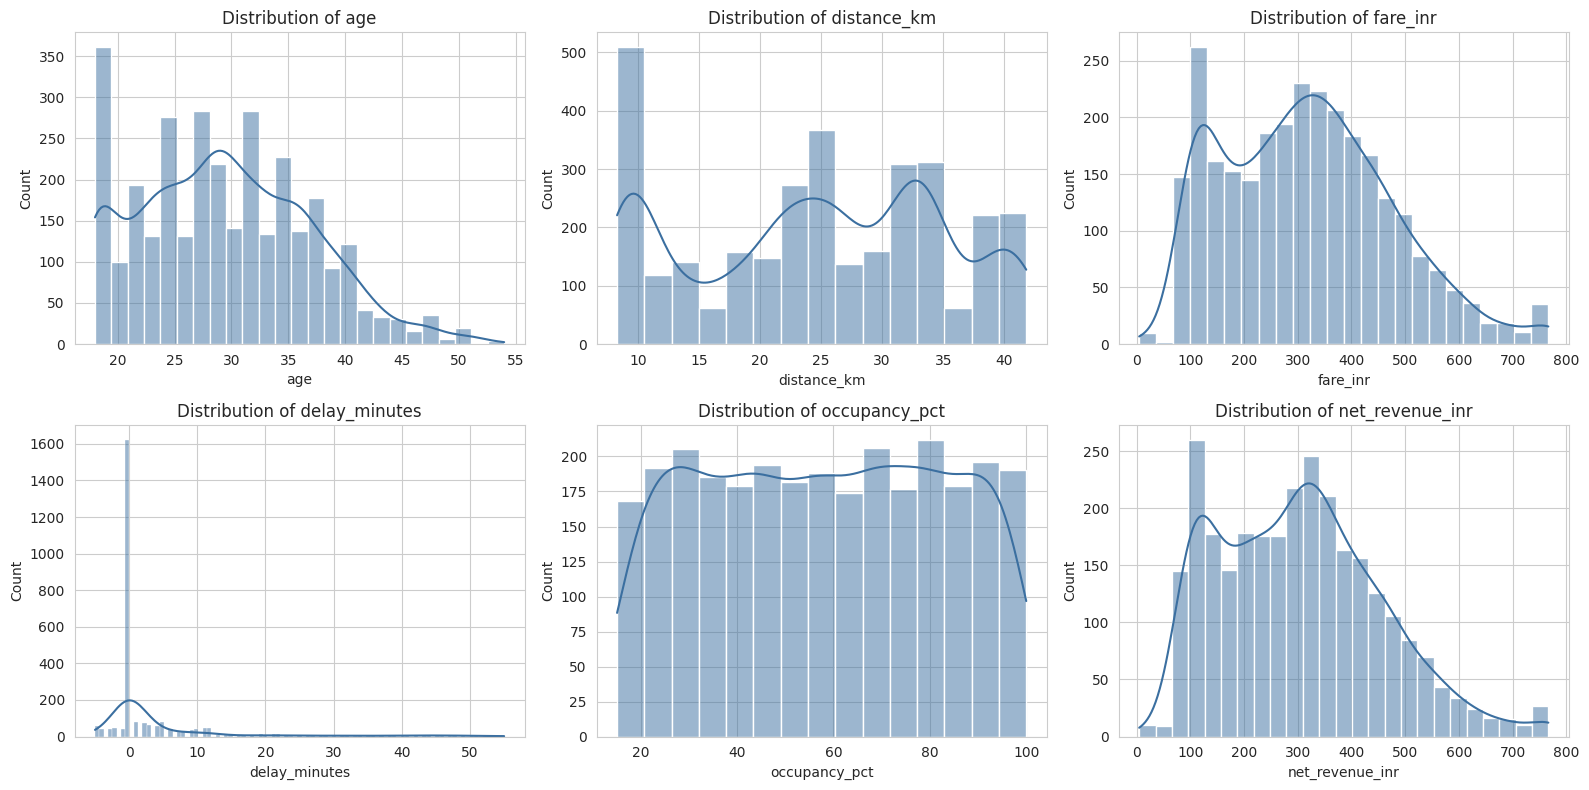

In [6]:
# Select important numerical columns for EDA and statistical analysis
num_cols_final = [
    "age", "distance_km",
    "fare_inr", "delay_minutes",
    "occupancy_pct", "net_revenue_inr"
]

# Create a 2 x 3 grid for six distribution plots
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Create a histogram for each numerical column
for ax, c in zip(axes.flat, num_cols_final):
    # Plot the distribution with a density curve
    sns.histplot(df[c].dropna(), kde=True, ax=ax, color="#3b6fa0")

    # Set the chart title
    ax.set_title(f"Distribution of {c}")

# Adjust spacing between plots
plt.tight_layout()
plt.show()

**4.2 Numerical Boxplots**

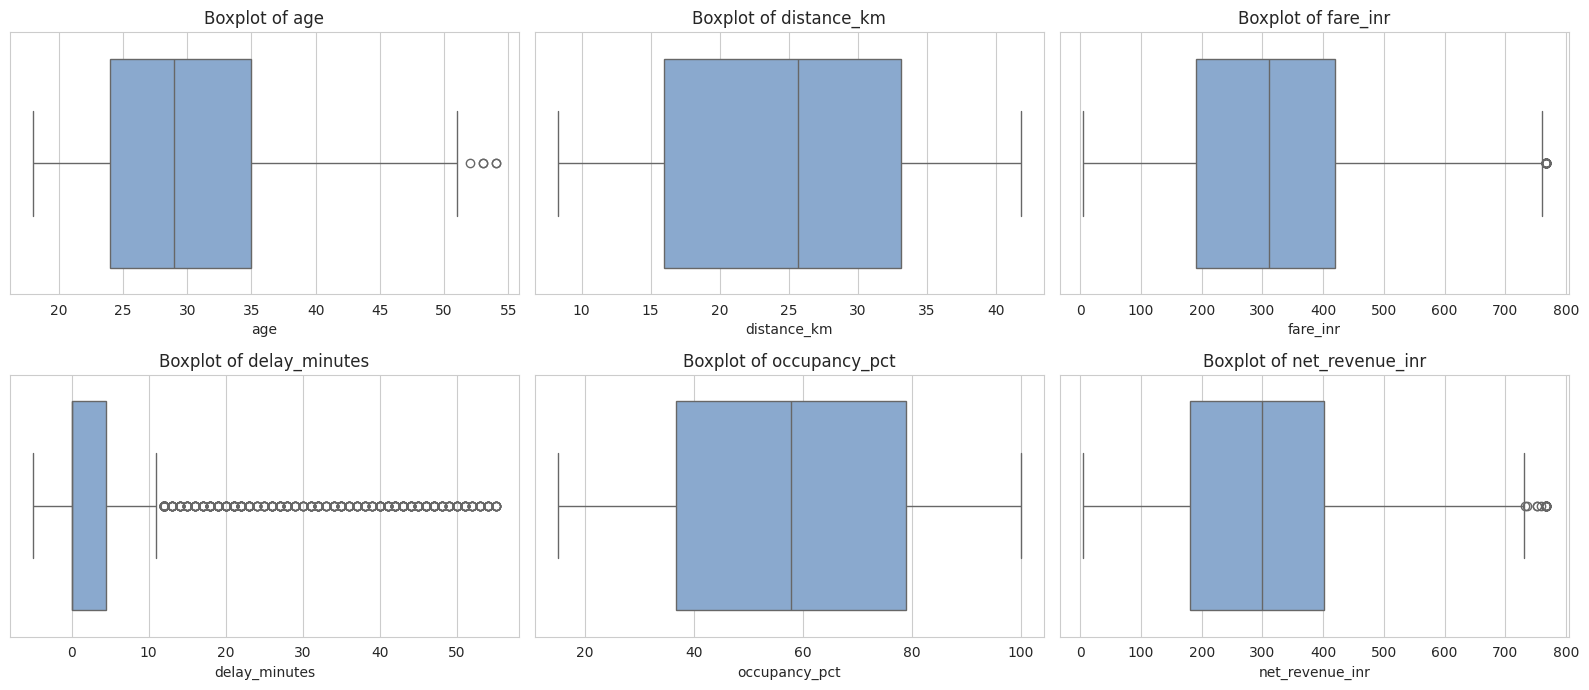

In [7]:
# Create a 2 x 3 grid for boxplots
fig, axes = plt.subplots(2, 3, figsize=(16, 7))

# Create a boxplot for each numerical column
for ax, c in zip(axes.flat, num_cols_final):
    # Plot the distribution and possible outliers
    sns.boxplot(x=df[c], ax=ax, color="#7fa8d9")

    # Set the chart title
    ax.set_title(f"Boxplot of {c}")

# Adjust the layout
plt.tight_layout()
plt.show()

**4.3 Descriptive Statistics**

In [8]:
# Calculate important descriptive statistics
summary_stats = df[num_cols_final].agg(
    ["mean", "median", "std",

    # Get the first mode value if a mode exists
    lambda s: (s.mode().iloc[0]
               if not s.mode().empty
               else np.nan),
               "skew", "kurt"])

# Rename the rows for better readability
summary_stats.index = ["mean", "median", "std", "mode", "skew", "kurtosis"]
summary_stats

,age,distance_km,fare_inr,delay_minutes,occupancy_pct,net_revenue_inr
mean,29.445000,24.738375,317.678281,5.209056,57.855147,304.076229
median,29.000000,25.700000,311.000000,0.000000,57.900000,300.000000
std,7.501554,10.291220,156.005937,11.919960,24.508039,152.124734
mode,18.000000,8.400000,766.500000,0.000000,57.800000,766.500000
skew,0.359248,-0.132789,0.455582,2.517691,-0.008881,0.518000
kurtosis,-0.382112,-1.129204,-0.225114,5.669984,-1.209838,-0.093902


**4.4 Categorical Analysis**

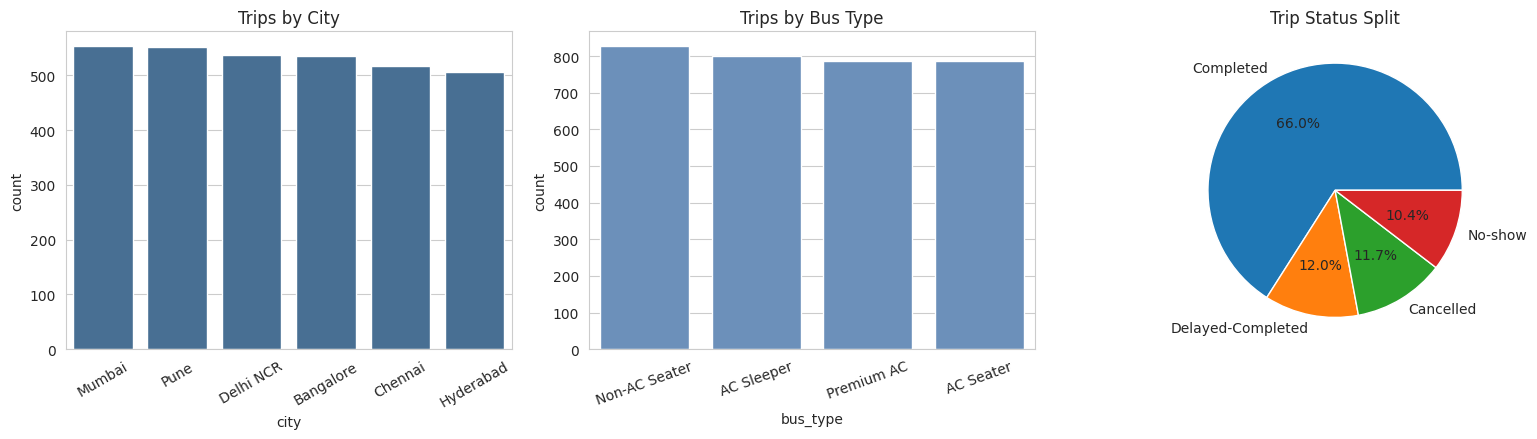

In [9]:
# Create three charts in one row
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Count trips by city
sns.countplot(
    data=df, x="city",
    order=df["city"].value_counts().index, ax=axes[0],
    color="#3b6fa0"
)

axes[0].set_title("Trips by City")
axes[0].tick_params(axis="x", rotation=30)

# Count trips by bus type
sns.countplot(
    data=df, x="bus_type",
    order=df["bus_type"].value_counts().index, ax=axes[1],
    color="#5f8fc7"
)

axes[1].set_title("Trips by Bus Type")
axes[1].tick_params(axis="x", rotation=20)

# Show the percentage split of trip status
df["trip_status"].value_counts().plot.pie(
    autopct="%1.1f%%",
    ax=axes[2], ylabel=""
)

axes[2].set_title("Trip Status Split")

# Adjust the layout
plt.tight_layout()
plt.show()

## **5. Bivariate Analysis**

**Numerical vs Numerical:** scatter plot + correlation coefficient.

**Numerical vs Categorical:** box plot / bar plot of mean by category.

**Categorical vs Categorical:** cross-tabulation, stacked bar chart.

**5.1 Fare vs Distance**

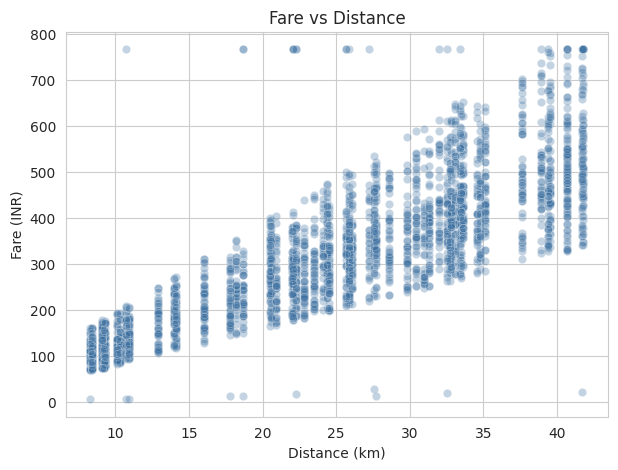

Pearson r = 0.846  (p = 0.00e+00)


In [59]:
# Remove rows where distance or fare is missing
# so that both the scatter plot and correlation use valid records
pearson_data = df[
    ["distance_km", "fare_inr"]
].dropna()

# Create a scatter plot to study the relationship
# between distance travelled and fare
fig, ax = plt.subplots(figsize=(7, 5))

sns.scatterplot(
    data=pearson_data,
    x="distance_km", y="fare_inr",
    alpha=0.3, ax=ax,
    color="#3b6fa0"
)
ax.set_title("Fare vs Distance")

ax.set_xlabel("Distance (km)")
ax.set_ylabel("Fare (INR)")
plt.show()

# Calculate Pearson correlation and p-value
pearson_r, pearson_p = stats.pearsonr(
    pearson_data["distance_km"],
    pearson_data["fare_inr"]
)

# Display the correlation result
print(f"Pearson r = {pearson_r:.3f}  (p = {pearson_p:.2e})")

**5.2 Fare by Bus Type**

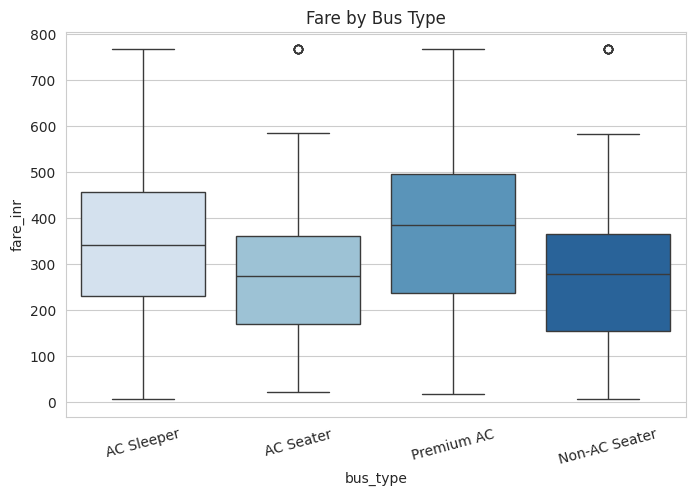

In [11]:
# Create a boxplot to compare fare distribution
# across different bus types
fig, ax = plt.subplots(figsize=(8, 5))

# Use bus_type as hue to avoid the Seaborn warning
sns.boxplot(
    data=df,
    x="bus_type",
    y="fare_inr",
    hue="bus_type",
    legend=False,
    palette="Blues",
    ax=ax
)

# Set chart title
ax.set_title("Fare by Bus Type")

# Rotate labels for better readability
plt.xticks(rotation=15)
plt.show()

**5.3 Average Rating by City**

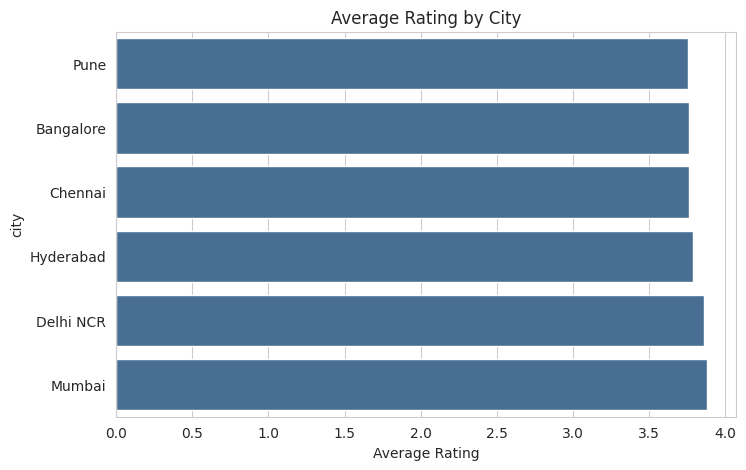

In [12]:
# Sort cities based on their average rating
order = df.groupby("city")["rating"].mean().sort_values().index

# Create the chart
fig, ax = plt.subplots(figsize=(8, 5))

# Seaborn automatically calculates the mean rating for each city
sns.barplot(
    data=df, y="city",
    x="rating", order=order,
    color="#3b6fa0", errorbar=None,
    ax=ax
)

# Add chart labels
ax.set_title("Average Rating by City")
ax.set_xlabel("Average Rating")
plt.show()

**5.4 Trip Status by City**

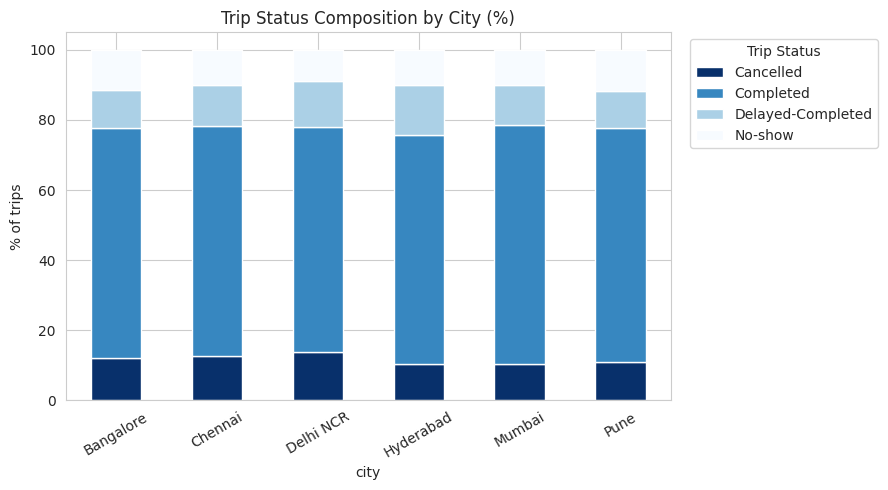

trip_status,Cancelled,Completed,Delayed-Completed,No-show
city,,,,
Bangalore,12.0,65.6,10.8,11.6
Chennai,12.6,65.6,11.8,10.1
Delhi NCR,13.8,64.1,13.2,8.9
Hyderabad,10.5,65.2,14.2,10.1
Mumbai,10.3,68.4,11.4,9.9
Pune,10.9,66.8,10.5,11.8


In [13]:
# Calculate the percentage of each trip status within every city
ct = (
    pd.crosstab(
        df["city"], df["trip_status"],
        normalize="index") * 100
    )

# Create a stacked bar chart
ct.plot(
    kind="bar", stacked=True,
    figsize=(9, 5), colormap="Blues_r"
    )

# Add chart title and labels
plt.title("Trip Status Composition by City (%)")
plt.ylabel("% of trips")

# Rotate city labels
plt.xticks(rotation=30)

# Place the legend outside the chart
plt.legend(
    title="Trip Status",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
    )

# Adjust the layout
plt.tight_layout()
plt.show()

# Display percentage values
ct.round(1)

## **6. Multivariate Analysis**

Pair plot across numerical columns, correlation heatmap, grouped box plots with a categorical `hue`, and a facet grid split by city.

**6.1 Pair Plot**

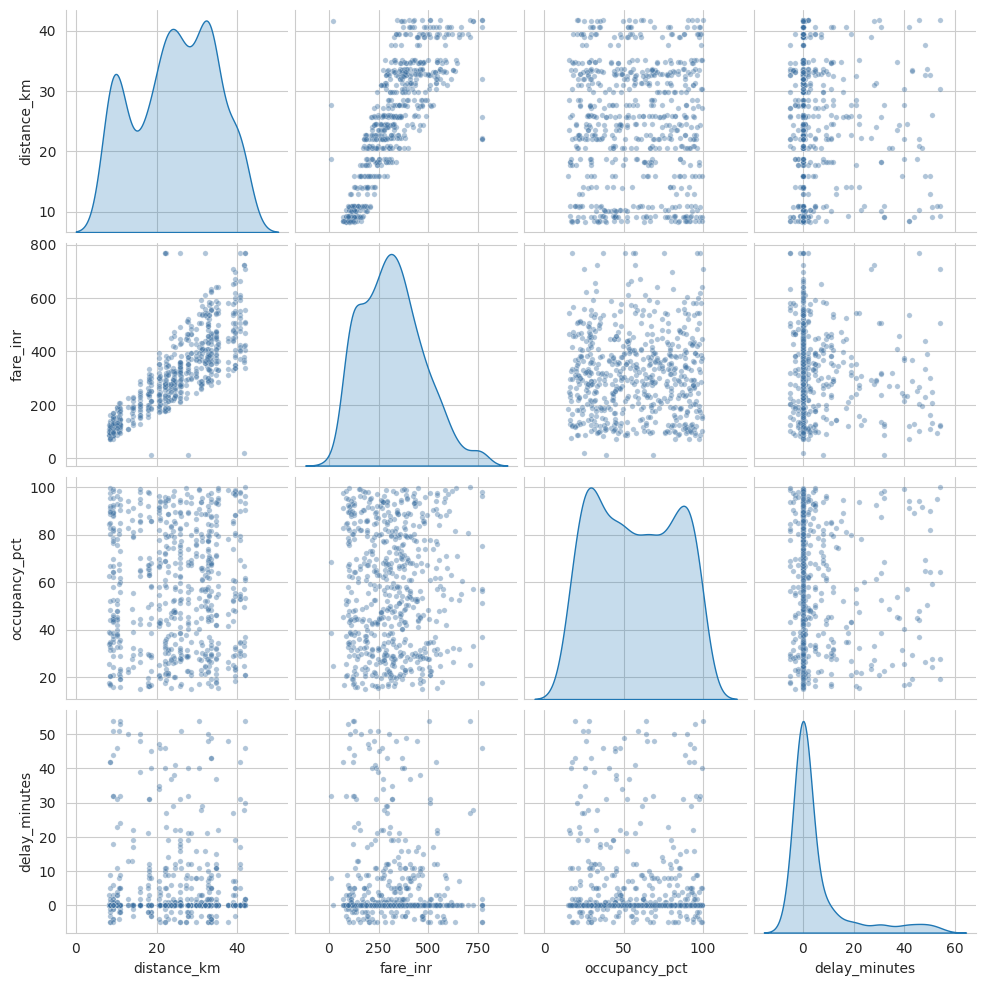

In [14]:
# Select important numerical columns
cols = ["distance_km", "fare_inr", "occupancy_pct", "delay_minutes"]

# Remove missing values and take a sample
# to make the pairplot faster and easier to read
sample_df = df[cols].dropna().sample(n=min(600, len(df)), random_state=42)

# Create pairwise relationship plots
sns.pairplot(
    sample_df,
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 15, "color": "#3b6fa0"}
)
plt.show()

**6.2 Correlation Heatmap**

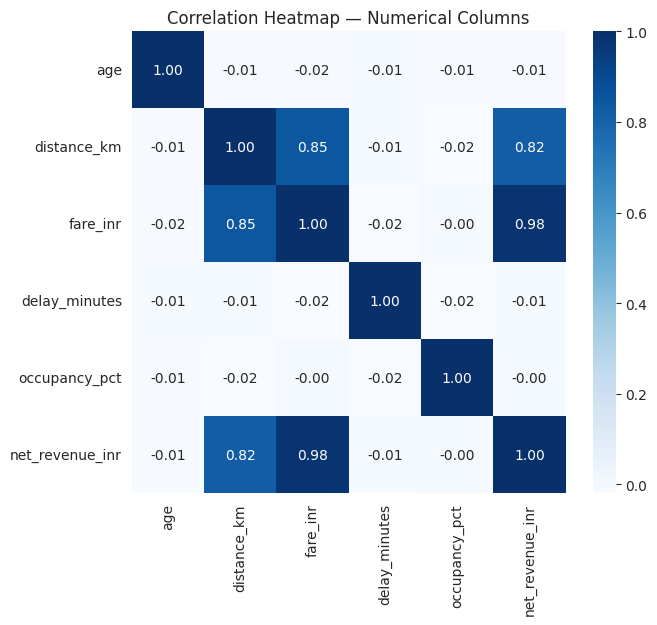

In [15]:
# Calculate the correlation between numerical columns
corr = df[num_cols_final].corr(numeric_only=True)

# Create a figure
fig, ax = plt.subplots(figsize=(7, 6))

# Create the correlation heatmap
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", ax=ax)

# Add the chart title
ax.set_title("Correlation Heatmap — Numerical Columns")
plt.show()

**6.3 Fare by City and Bus Type**

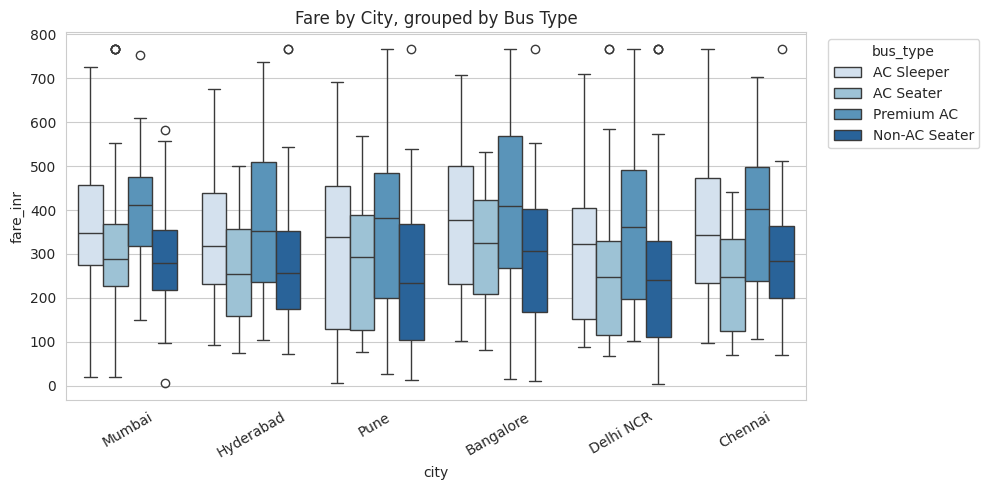

In [16]:
# Create a figure
fig, ax = plt.subplots(figsize=(10, 5))

# Compare fare distribution across cities
# and separate the values by bus type
sns.boxplot(
    data=df,
    x="city",
    y="fare_inr",
    hue="bus_type",
    palette="Blues",
    ax=ax
)

# Add chart title
ax.set_title("Fare by City, grouped by Bus Type")
# Rotate city labels
ax.tick_params(axis="x", rotation=30)

# Move the legend outside the chart
sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

**6.4 Delay Distribution by City**

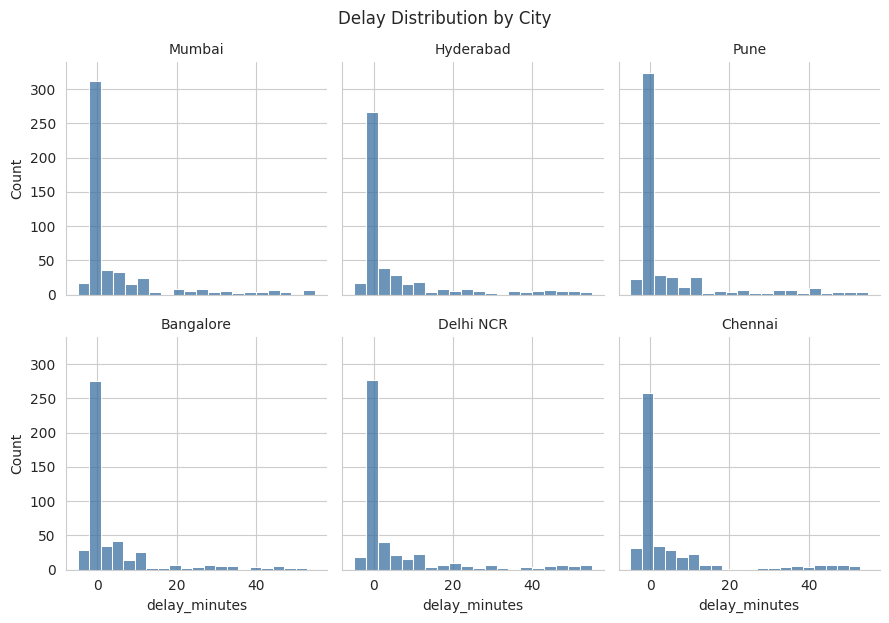

In [17]:
# Create separate delay distribution charts for each city
g = sns.FacetGrid(df, col="city", col_wrap=3, height=3)

# Plot delay distribution for every city
g.map_dataframe(sns.histplot, x="delay_minutes", color="#3b6fa0", bins=20)

# Display city names as subplot titles
g.set_titles("{col_name}")

# Add an overall chart title
g.fig.suptitle("Delay Distribution by City", y=1.03)
plt.show()

## **7. Hypothesis Testing**

State H₀ (no effect/difference) and H₁ (there is one), then choose the test based on variable types, checking normality (Shapiro-Wilk, on a sample since N is large) and equal variance (Levene's test) first.

### 7.1 Distance and Fare — Pearson correlation test between distance_km and fare_inr.

- H₀: There is no linear correlation between distance and fare.
- H₁: There is a linear correlation between distance and fare.

In [61]:
# Remove rows where distance or fare is missing
pearson_data = df[
    ["distance_km", "fare_inr"]
].dropna()

# Calculate Pearson correlation between distance and fare
r, p = stats.pearsonr(pearson_data["distance_km"], pearson_data["fare_inr"])

# Display the correlation coefficient and p-value
print(
    f"Pearson r = {r:.3f}",
    f"p-value = {p:.2e}"
    )

# Check whether the result is statistically significant
print(
    "Reject H0 -> significant correlation"
    if p < 0.05
    else "Fail to reject H0"
    )

Pearson r = 0.846 p-value = 0.00e+00
Reject H0 -> significant correlation


### 7.2 Peak Hour and Trip Delay — Independent t-test comparing `delay_minutes` between peak-hour and non-peak-hour trips.

- H₀: Mean delay is the same for peak-hour and non-peak-hour trips.
- H₁: Mean delay differs between the two groups.

In [19]:
# Select peak-hour delay values
peak = df.loc[
    df["is_peak_hour"] == True,
    "delay_minutes"].dropna()

# Select non-peak-hour delay values
non_peak = df.loc[
    df["is_peak_hour"] == False,
    "delay_minutes"].dropna()

# Test normality using a sample of peak-hour data
# A sample is used because Shapiro-Wilk can be sensitive to large datasets
shapiro_peak = stats.shapiro(
    peak.sample(
        min(500, len(peak)),
        random_state=1)
    )

# Test whether the group variances are equal
levene_stat, levene_p = stats.levene(peak, non_peak)

# Display assumption test results
print(f"Shapiro-Wilk (peak sample) p = {shapiro_peak.pvalue:.4f}")
print(f"Levene's test p = {levene_p:.4f}")

# Run the independent t-test
t_stat, t_p = stats.ttest_ind(peak, non_peak, equal_var=(levene_p > 0.05))

# Display t-test results
print(f"\nt-statistic = {t_stat:.3f}, p-value = {t_p:.4f}")
print(f"Peak mean delay = {peak.mean():.1f} min | Non-peak mean delay = {non_peak.mean():.1f} min")

# Interpret the hypothesis test
print(
    "Reject H0 -> delay differs by peak hour"
    if t_p < 0.05
    else "Fail to reject H0"
    )

Shapiro-Wilk (peak sample) p = 0.0000
Levene's test p = 0.6068

t-statistic = 0.550, p-value = 0.5824
Peak mean delay = 5.4 min | Non-peak mean delay = 5.1 min
Fail to reject H0


### 7.3 Bus Type and Fare — One-Way ANOVA comparing `fare_inr` across `bus_type`.

- H₀: Mean fare is the same across all bus types.
- H₁: At least one bus type has a different mean fare.

In [20]:
# Create fare groups for each bus type
groups = [
    g["fare_inr"].dropna().values
    for _, g in df.groupby("bus_type")
    ]

# Test whether group variances are equal
levene_stat, levene_p = stats.levene(*groups)

# Run One-Way ANOVA
f_stat, anova_p = stats.f_oneway(*groups)


# Display Levene's test result
print(f"Levene's test p = {levene_p:.4f}")

# Display ANOVA results
print(f"ANOVA F = {f_stat:.2f}, p-value = {anova_p:.2e}")

# Interpret the result
print(
    "Reject H0 -> fare differs by bus type"
    if anova_p < 0.05
    else "Fail to reject H0"
    )

# Display mean fare for every bus type
print(df.groupby("bus_type")["fare_inr"].mean().round(1))

Levene's test p = 0.0000
ANOVA F = 86.53, p-value = 1.46e-53
Reject H0 -> fare differs by bus type
bus_type
AC Seater        276.0
AC Sleeper       343.8
Non-AC Seater    272.9
Premium AC       379.3
Name: fare_inr, dtype: float64


### 7.4 City and Trip Status — Chi-Square test of independence between `city` and `trip_status` (is cancellation/no-show behavior associated with city?).

- H₀: `city` and `trip_status` are independent.
- H₁: `city` and `trip_status` are associated.

In [21]:
# Create a contingency table between city and trip status
contingency = pd.crosstab(df["city"], df["trip_status"])

# Run the Chi-Square test of independence
chi2, chi_p, dof, expected = stats.chi2_contingency(contingency)

# Display test results
print(f"Chi-square = {chi2:.2f}, dof = {dof}, p-value = {chi_p:.4f}")

# Interpret whether city and trip status are associated
print(
    "Reject H0 -> city and trip_status are associated"
    if chi_p < 0.05
    else "Fail to reject H0"
    )

# Display the contingency table
contingency

Chi-square = 12.80, dof = 15, p-value = 0.6181
Fail to reject H0


trip_status,Cancelled,Completed,Delayed-Completed,No-show
city,,,,
Bangalore,64,351,58,62
Chennai,65,339,61,52
Delhi NCR,74,344,71,48
Hyderabad,53,330,72,51
Mumbai,57,378,63,55
Pune,60,369,58,65


## **8. Key Performance Indicators (KPIs) Analysis**

The following KPIs summarize the overall revenue, trip activity, operational performance, and customer experience of the CityFlo bus service.



- **Net Revenue** (`net_revenue_inr` summed)
- **Total Trips**
- **Unique Customers**
- **Completed Trips**
- **Cancellation Rate** (Cancelled + No-show ÷ total)
- **On-Time Performance** (`delay_minutes` ≤ 5)
- **Avg Occupancy**
- **Avg Rating**
- **Complaint Rate**

In [22]:
# Calculate important business KPIs
kpis = {
    "Net Revenue": f"₹{df['net_revenue_inr'].sum():,.2f}",
    "Total Trips": f"{len(df):,}",
    "Unique Customers" : f"{df["customer_id"].nunique():,}",
    "Completed Trips": f"{(df['trip_status'].isin(['Completed', 'Delayed-Completed'])).sum():,}",
    "Cancellation Rate": f"{(df['trip_status'].isin(['Cancelled', 'No-show']).mean() * 100):.2f}%",
    "On-Time Performance": f"{((df['delay_minutes'] <= 5).mean() * 100):.2f}%",
    "Avg Occupancy": f"{df['occupancy_pct'].mean():.2f}%",
    "Avg Rating": f"{df['rating'].mean():.2f} / 5.0",
    "Complaint Rate": f"{(df['complaint_raised'] == True).mean() * 100:.2f}%",
}

# Convert the KPI dictionary into a DataFrame
kpi_df = pd.DataFrame.from_dict(kpis, orient="index", columns=["Value"])

# Display the KPI summary
kpi_df

,Value
Net Revenue,"₹859,623.50"
Total Trips,"3,200"
Unique Customers,"1,251"
Completed Trips,"2,494"
Cancellation Rate,22.06%
On-Time Performance,68.75%
Avg Occupancy,57.86%
Avg Rating,3.80 / 5.0
Complaint Rate,6.41%


## **9. Dashboard Preparation & Visualisation**

The analysis results were used to design the final four-page Looker Studio dashboard.

The final Looker Studio dashboard was designed using the cleaned dataset
and the findings from the data analysis.

The dashboard is divided into four pages:
* Page 1. Executive Overview
* Page 2. Revenue & Demand Analysis
* Page 3. Operations & Service Performance
* Page 4. Customer & Booking Insights

### **Page 1 — Executive Overview**

This page provides an overall view of revenue, trip activity, trip status and bus type performance.

**9.1.1 Monthly Revenue & Trip Volume**

Looker Chart: Combo Chart

In [23]:
# Create month names from the trip date
df["trip_month_name"] = df["trip_date"].dt.strftime("%B")

# Define the correct month order
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

# Convert month names into an ordered categorical column
df["trip_month_name"] = pd.Categorical(
    df["trip_month_name"],
    categories=month_order,
    ordered=True
)

# Calculate monthly net revenue and total trip volume
monthly_revenue_trips = (
    df.groupby("trip_month_name", observed=False)
    .agg(
        net_revenue=("net_revenue_inr", "sum"),
        total_trips=("trip_id", "count")
    )
    .reset_index()
)

# Rename the month column for better readability
monthly_revenue_trips.rename(
    columns={"trip_month_name": "month"},
    inplace=True
)

# Display the monthly revenue and trip volume summary
display(
    monthly_revenue_trips.style.format(
        {
            "net_revenue": "₹{:,.0f}",
            "total_trips": "{:,.0f}"
        }
    ).hide(axis="index")
)

month,net_revenue,total_trips
January,"₹71,996",262
February,"₹64,868",242
March,"₹79,246",299
April,"₹80,376",278
May,"₹67,226",255
June,"₹65,696",252
July,"₹71,854",279
August,"₹74,276",275
September,"₹65,692",251
October,"₹72,557",265


**9.1.2 Net Revenue by City**

Looker Chart: Bar Chart

In [24]:
# Calculate total net revenue for each city
city_revenue = (
    df.groupby("city")["net_revenue_inr"]
    .sum()
    .reset_index(name="net_revenue")
)

# Sort cities from highest to lowest net revenue
city_revenue = city_revenue.sort_values(
    "net_revenue",
    ascending=False
)

# Display the city-wise net revenue summary
display(
    city_revenue.style.format(
        {
            "net_revenue": "₹{:,.0f}"
        }
    ).hide(axis="index")
)

city,net_revenue
Mumbai,"₹157,032"
Pune,"₹153,194"
Bangalore,"₹148,379"
Chennai,"₹140,450"
Hyderabad,"₹135,077"
Delhi NCR,"₹125,492"


**9.1.3 Trip Status Distribution**

Looker Chart: Donut Chart

In [25]:
# Count the number of trips for each trip status
trip_status_summary = (
    df["trip_status"]
    .value_counts()
    .reset_index()
)

# Rename columns for better readability
trip_status_summary.columns = [
    "trip_status",
    "trip_count"
]

# Calculate the percentage contribution of each trip status
trip_status_summary["percentage"] = (
    trip_status_summary["trip_count"]
    / trip_status_summary["trip_count"].sum()
    * 100
)

# Display the trip status distribution
display(
    trip_status_summary.style.format(
        {
            "trip_count": "{:,.0f}",
            "percentage": "{:.1f}%"
        }
    ).hide(axis="index")
)

trip_status,trip_count,percentage
Completed,"2,111",66.0%
Delayed-Completed,383,12.0%
Cancelled,373,11.7%
No-show,333,10.4%


**9.1.4 Trip Volume by Bus Type**

Looker Chart: Treemap

In [26]:
# Count the total number of trips for each bus type
bus_type_summary = (
    df["bus_type"]
    .value_counts()
    .reset_index()
)

# Rename columns for better readability
bus_type_summary.columns = [
    "bus_type",
    "total_trips"
]

# Sort bus types from highest to lowest trip volume
bus_type_summary = bus_type_summary.sort_values(
    "total_trips",
    ascending=False
)

# Display the trip volume by bus type
display(
    bus_type_summary.style.format(
        {
            "total_trips": "{:,.0f}"
        }
    ).hide(axis="index")
)

bus_type,total_trips
Non-AC Seater,826
AC Sleeper,801
Premium AC,787
AC Seater,786


### **Page 2 — Revenue & Demand Analysis**

This page focuses on monthly revenue trends, route-level demand, booking channels, subscription types and weekday trip demand across cities.

**9.2.1 Monthly Net Revenue Trend**

Looker Chart: Time Series Chart

In [27]:
# Calculate total net revenue for each month
monthly_revenue = (
    df.groupby("trip_month_name", observed=False)["net_revenue_inr"]
    .sum()
    .reset_index(name="net_revenue")
)

# Rename the month column for better readability
monthly_revenue.rename(
    columns={"trip_month_name": "month"},
    inplace=True
)

# Display the monthly net revenue summary
display(
    monthly_revenue.style.format(
        {
            "net_revenue": "₹{:,.1f}"
        }
    ).hide(axis="index")
)

month,net_revenue
January,"₹71,996.5"
February,"₹64,867.5"
March,"₹79,245.5"
April,"₹80,376.0"
May,"₹67,226.0"
June,"₹65,696.5"
July,"₹71,854.5"
August,"₹74,276.5"
September,"₹65,691.5"
October,"₹72,557.0"


**9.2.2 Route Demand vs Net Revenue**

Looker Chart: Scatter Chart

In [28]:
# Calculate total trip demand and net revenue for each route
route_demand_revenue = (
    df.groupby("route_name")
    .agg(
        total_trips=("trip_id", "count"),
        net_revenue=("net_revenue_inr", "sum")
    )
    .reset_index()
)

# Sort routes from highest to lowest net revenue
route_demand_revenue = route_demand_revenue.sort_values(
    "net_revenue",
    ascending=False
)

# Display the route-level demand and revenue summary
display(
    route_demand_revenue.style.format(
        {
            "total_trips": "{:,.0f}",
            "net_revenue": "₹{:,.1f}"
        }
    ).hide(axis="index")
)

route_name,total_trips,net_revenue
Kharadi - Magarpatta,62,"₹30,084.0"
Indirapuram - Rohini,54,"₹26,120.5"
Velachery - Tambaram,60,"₹25,316.0"
Thane West - BKC,60,"₹24,864.5"
Shivajinagar - Hinjewadi Phase 1,54,"₹24,757.0"
Whitefield - Yelahanka,61,"₹23,284.0"
Kukatpally - Miyapur,59,"₹23,070.0"
Kukatpally - Gachibowli,54,"₹23,021.5"
Electronic City - Bannerghatta Road,53,"₹21,298.5"
Guindy - Anna Nagar,54,"₹20,383.0"


**9.2.3 Net Revenue by Booking Channel**

Looker Chart: Vertical Bar Chart

In [29]:
# Calculate total net revenue for each booking channel
booking_channel_revenue = (
    df.groupby("booking_channel")["net_revenue_inr"]
    .sum()
    .reset_index(name="net_revenue")
)

# Sort booking channels from highest to lowest net revenue
booking_channel_revenue = booking_channel_revenue.sort_values(
    "net_revenue",
    ascending=False
)

# Display booking channel-wise net revenue
display(
    booking_channel_revenue.style.format(
        {
            "net_revenue": "₹{:,.1f}"
        }
    ).hide(axis="index")
)

booking_channel,net_revenue
Website,"₹225,059.5"
Corporate Portal,"₹224,631.0"
Mobile App,"₹207,995.0"
Kiosk,"₹201,938.0"


**9.2.4 Revenue Contribution by Subscription Type**

Looker Chart: Pie Chart

In [30]:
# Calculate total net revenue for each subscription type
subscription_revenue = (
    df.groupby("subscription_type")["net_revenue_inr"]
    .sum()
    .reset_index(name="net_revenue")
)

# Calculate each subscription type's percentage contribution
# to the total net revenue
subscription_revenue["percentage"] = (
    subscription_revenue["net_revenue"]
    / subscription_revenue["net_revenue"].sum()
    * 100
)

# Sort subscription types from highest to lowest net revenue
subscription_revenue = subscription_revenue.sort_values(
    "net_revenue",
    ascending=False
)

# Display subscription-wise revenue contribution
display(
    subscription_revenue.style.format(
        {
            "net_revenue": "₹{:,.1f}",
            "percentage": "{:.1f}%"
        }
    ).hide(axis="index")
)

subscription_type,net_revenue,percentage
Monthly Pass,"₹220,160.0",25.6%
Weekly Pass,"₹214,891.5",25.0%
Corporate Plan,"₹214,738.0",25.0%
Single Ride,"₹209,834.0",24.4%


**9.2.5 Trip Demand by City & Weekday**

Looker Chart: Pivot Table With Heatmap

In [31]:
# Define the correct chronological order of weekdays
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# Convert trip weekday into an ordered categorical column
df["trip_weekday"] = pd.Categorical(
    df["trip_weekday"],
    categories=weekday_order,
    ordered=True
)

# Count total trips for each city and weekday
city_weekday_demand = (
    df.groupby(
        ["city", "trip_weekday"],
        observed=False
    )
    .size()
    .reset_index(name="total_trips")
)

# Create a pivot table for the dashboard heatmap
city_weekday_pivot = city_weekday_demand.pivot(
    index="city",
    columns="trip_weekday",
    values="total_trips"
)

# Display the city and weekday trip demand table
display(
    city_weekday_pivot.style.format(
        "{:,.0f}"
    )
)

trip_weekday,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
city,,,,,,,
Bangalore,85,72,63,79,84,70,82
Chennai,86,68,64,79,68,75,77
Delhi NCR,73,74,89,87,70,68,76
Hyderabad,57,92,61,64,81,74,77
Mumbai,97,71,67,83,89,72,74
Pune,65,106,66,89,92,55,79


### **Page 3 — Operations & Service Performance**

This page focuses on trip delays, trip status, bus occupancy, service punctuality and cancellation reasons.

**9.3.1 Average Delay by City**

Looker Chart: Vertical Bar Chart

In [32]:
# Select successfully completed trips
# Both normal completed and delayed-completed trips are included
completed_df = df[
    df["trip_status"].isin(
        ["Completed", "Delayed-Completed"]
    )
].copy()

# Calculate average delay for each city
city_delay = (
    completed_df.groupby("city")["delay_minutes"]
    .mean()
    .reset_index(name="avg_delay_minutes")
)

# Sort cities from highest to lowest average delay
city_delay = city_delay.sort_values(
    "avg_delay_minutes",
    ascending=False
)

# Display the city-wise average delay summary
display(
    city_delay.style.format(
        {
            "avg_delay_minutes": "{:.2f}"
        }
    ).hide(axis="index")
)

city,avg_delay_minutes
Hyderabad,6.68
Delhi NCR,6.47
Chennai,6.21
Mumbai,5.44
Pune,5.40
Bangalore,5.30


**9.3.2 Trip Status by City**

Looker Chart: 100% Stacked Bar Chart

In [33]:
# Count trips for each city and trip status
city_trip_status = (
    df.groupby(["city", "trip_status"])
    .size()
    .reset_index(name="trip_count")
)

# Calculate the percentage of each trip status
# within every city
city_trip_status["percentage"] = (
    city_trip_status["trip_count"]
    / city_trip_status.groupby("city")["trip_count"]
    .transform("sum")
    * 100
)

# Sort the results by city and trip status
city_trip_status = city_trip_status.sort_values(
    ["city", "trip_status"]
)

# Display city-wise trip status composition
display(
    city_trip_status.style.format(
        {
            "trip_count": "{:,.0f}",
            "percentage": "{:.2f}%"
        }
    ).hide(axis="index")
)

city,trip_status,trip_count,percentage
Bangalore,Cancelled,64,11.96%
Bangalore,Completed,351,65.61%
Bangalore,Delayed-Completed,58,10.84%
Bangalore,No-show,62,11.59%
Chennai,Cancelled,65,12.57%
Chennai,Completed,339,65.57%
Chennai,Delayed-Completed,61,11.80%
Chennai,No-show,52,10.06%
Delhi NCR,Cancelled,74,13.78%
Delhi NCR,Completed,344,64.06%


**9.3.3 Bus Type Occupancy & Delay**

Looker Chart: Combo Chart

In [34]:
# Calculate average occupancy and average delay
# for each bus type using completed trips
bus_type_performance = (
    completed_df.groupby("bus_type")
    .agg(
        avg_occupancy=("occupancy_pct", "mean"),
        avg_delay_minutes=("delay_minutes", "mean")
    )
    .reset_index()
)

# Sort bus types from highest to lowest average occupancy
bus_type_performance = bus_type_performance.sort_values(
    "avg_occupancy",
    ascending=False
)

# Display bus type occupancy and delay summary
display(
    bus_type_performance.style.format(
        {
            "avg_occupancy": "{:.2f}",
            "avg_delay_minutes": "{:.2f}"
        }
    ).hide(axis="index")
)

bus_type,avg_occupancy,avg_delay_minutes
AC Sleeper,59.12,5.50
Non-AC Seater,58.01,6.43
AC Seater,57.22,6.04
Premium AC,56.22,5.64


**9.3.4 Trip Delay Status**

Looker Chart: Donut Chart

In [35]:
# Create delay categories for successfully completed trips
completed_df["delay_status"] = pd.cut(
    completed_df["delay_minutes"],
    bins=[-float("inf"), 5, 15, 30, float("inf")],
    labels=[
        "On Time (0-5 min)",
        "Minor Delay (6-15 min)",
        "Moderate Delay (16-30 min)",
        "Severe Delay (30+ min)"
    ]
)

# Count the number of completed trips in each delay category
delay_status_summary = (
    completed_df["delay_status"]
    .value_counts(sort=False)
    .reset_index()
)

# Rename columns for better readability
delay_status_summary.columns = [
    "delay_status",
    "trip_count"
]

# Calculate the percentage contribution
# of each delay category
delay_status_summary["percentage"] = (
    delay_status_summary["trip_count"]
    / delay_status_summary["trip_count"].sum()
    * 100
)

# Display the delay status summary
display(
    delay_status_summary.style.format(
        {
            "trip_count": "{:,.0f}",
            "percentage": "{:.1f}%"
        }
    ).hide(axis="index")
)

delay_status,trip_count,percentage
On Time (0-5 min),"1,867",74.9%
Minor Delay (6-15 min),293,11.7%
Moderate Delay (16-30 min),136,5.5%
Severe Delay (30+ min),198,7.9%


**9.3.5 Cancellation Reasons**

Looker Chart: Treemap

In [36]:
# Select cancelled and no-show trips
cancelled_df = df[
    df["trip_status"].isin(
        ["Cancelled", "No-show"]
    )
].copy()

# Count trips for each cancellation reason
cancellation_reason_summary = (
    cancelled_df["cancellation_reason"]
    .value_counts()
    .reset_index()
)

# Rename columns for better readability
cancellation_reason_summary.columns = [
    "cancellation_reason",
    "trip_count"
]

# Calculate the percentage contribution
# of each cancellation reason
cancellation_reason_summary["percentage"] = (
    cancellation_reason_summary["trip_count"]
    / cancellation_reason_summary["trip_count"].sum()
    * 100
)

# Display the cancellation reason summary
display(
    cancellation_reason_summary.style.format(
        {
            "trip_count": "{:,.0f}"
        }
    ).hide(axis="index")
)

cancellation_reason,trip_count,percentage
Customer Request,306,43.342776
Payment Failed,163,23.087819
Bus Breakdown,72,10.198300
Traffic/Weather,65,9.206799
Driver Unavailable,57,8.073654
Route Diverted,43,6.090652


### **Page 4 — Customer & Booking Insights**

This page focuses on customer demographics, ratings, complaints, payment preferences and booking channel behaviour.

**9.4.1 Gender Mix by Age Group**

Looker Chart: 100% Stacked Vertical Bar Chart

In [37]:
# Define the age groups shown in the dashboard
age_group_order = [
    "18-25",
    "26-35",
    "36-45",
    "46-60"
]

# Select only the age groups displayed in the dashboard
gender_age_data = df[
    df["age_group"].isin(age_group_order)
].copy()

# Convert age group into an ordered categorical column
gender_age_data["age_group"] = pd.Categorical(
    gender_age_data["age_group"],
    categories=age_group_order,
    ordered=True
)

# Count trips for each age group and gender
gender_age_summary = (
    gender_age_data.groupby(
        ["age_group", "gender"],
        observed=False
    )
    .size()
    .reset_index(name="trip_count")
)

# Calculate gender percentage within each age group
gender_age_summary["percentage"] = (
    gender_age_summary["trip_count"]
    / gender_age_summary.groupby(
        "age_group",
        observed=False
    )["trip_count"].transform("sum")
    * 100
)

# Display the gender mix by age group
display(
    gender_age_summary.style.format(
        {
            "trip_count": "{:,.0f}",
            "percentage": "{:.2f}%"
        }
    ).hide(axis="index")
)

age_group,gender,trip_count,percentage
18-25,Female,559,52.59%
18-25,Male,468,44.03%
18-25,Other,36,3.39%
26-35,Female,708,49.82%
26-35,Male,646,45.46%
26-35,Other,67,4.71%
36-45,Female,327,51.50%
36-45,Male,271,42.68%
36-45,Other,37,5.83%
46-60,Female,31,38.27%


**9.4.2 Customer Rating Distribution**

Looker Chart: Vertical Bar Chart

In [49]:
# Count the number of valid customer ratings
rating_summary = (
    df["rating"]
    .dropna()
    .value_counts()
    .sort_index()
    .reset_index()
)

# Rename columns for better readability
rating_summary.columns = [
    "rating",
    "rated_trips"
]


# Display the customer rating distribution
display(
    rating_summary.style.format(
        {
            "rating": "{:.0f} / 5",
            "rated_trips": "{:,.0f}"
        }
    ).hide(axis="index")
)

rating,rated_trips
1 / 5,108
2 / 5,195
3 / 5,469
4 / 5,618
5 / 5,755


**9.4.3 Customer Experience by City**

Looker Chart: Bubble Chart

In [62]:
# Calculate average customer rating
# and complaint rate for each city
customer_experience_city = (
    df.groupby("city")
    .agg(
        avg_rating=("rating", "mean"),

        complaint_rate=(
            "complaint_raised",
            lambda x: (x == True).mean() * 100
        ),

        unique_customers=("customer_id", "nunique")
    )
    .reset_index()
)

# Sort cities by average rating
customer_experience_city = (
    customer_experience_city
    .sort_values(
        "avg_rating",
        ascending=False
    )
)

# Display city-wise customer experience summary
display(
    customer_experience_city.style.format(
        {
            "avg_rating": "{:.2f}",
            "complaint_rate": "{:.1f}%",
            "unique_customers": "{:,.0f}"
        }
    ).hide(axis="index")
)

city,avg_rating,complaint_rate,unique_customers
Mumbai,3.88,5.8%,452
Delhi NCR,3.86,6.9%,428
Hyderabad,3.79,6.7%,426
Chennai,3.76,5.8%,442
Bangalore,3.76,6.9%,434
Pune,3.75,6.3%,465


**9.4.4 Payment Mode Usage**

Looker Chart: Pie Chart

In [55]:
# Count trips for each available payment mode
payment_mode_summary = (
    df["payment_mode"]
    .dropna()
    .value_counts()
    .reset_index()
)

# Rename columns for better readability
payment_mode_summary.columns = [
    "payment_mode",
    "total_trips"
]

# Calculate the percentage usage
# of each payment mode
payment_mode_summary["percentage"] = (
    payment_mode_summary["total_trips"]
    / payment_mode_summary["total_trips"].sum()
    * 100
)

# Display the payment mode usage summary
display(
    payment_mode_summary.style.format(
        {
            "total_trips": "{:,.0f}",
            "percentage": "{:.1f}%"
        }
    ).hide(axis="index")
)

payment_mode,total_trips,percentage
UPI,492,17.4%
Wallet,484,17.1%
Debit Card,470,16.6%
Cash,466,16.5%
Net Banking,458,16.2%
Credit Card,457,16.2%


**9.4.5 Payment Modes by Booking Channel**

Looker Chart: Pivot Table with Heatmap

In [56]:
# Create a pivot table showing the number of trips
# for each booking channel and payment mode
payment_booking_summary = pd.crosstab(
    df["booking_channel"],
    df["payment_mode"]
)

# Define the same booking channel order
# used in the dashboard
booking_channel_order = [
    "Website",
    "Corporate Portal",
    "Mobile App",
    "Kiosk"
]

# Define the payment mode order
# used in the dashboard
payment_mode_order = [
    "Cash",
    "Credit Card",
    "Debit Card",
    "Net Banking",
    "UPI",
    "Wallet"
]

# Arrange rows and columns in dashboard order
payment_booking_summary = (
    payment_booking_summary
    .reindex(
        index=booking_channel_order,
        columns=payment_mode_order
    )
)

# Add the total number of trips
# for each booking channel
payment_booking_summary["Grand total"] = (
    payment_booking_summary.sum(axis=1)
)

# Display the booking channel and payment mode summary
display(
    payment_booking_summary.style.format(
        "{:,.0f}"
    )
)

payment_mode,Cash,Credit Card,Debit Card,Net Banking,UPI,Wallet,Grand total
booking_channel,,,,,,,
Website,129,120,118,107,134,131,739
Corporate Portal,114,115,101,124,128,137,719
Mobile App,113,117,125,121,125,100,701
Kiosk,110,105,126,106,105,116,668


## **10. Key Findings**

- The dataset contains 3,200 bus trip records across six metro cities.
- Total net revenue was ₹859,623.50, with Mumbai generating the highest city-level revenue.
- A total of 2,494 trips were completed, while the overall cancellation rate was 22.06%.
- Customer Request was the most common cancellation reason, followed by Payment Failed.
- Overall On-Time Performance was 68.75%, while completed-trip delay analysis showed that most completed trips were within the 0–5 minute delay range.
- Revenue was distributed fairly evenly across booking channels and subscription types.
- The average customer rating was 3.80, with a complaint rate of 6.41%.
- Customer demand, revenue, operational performance and booking behaviour varied across cities, routes and service categories.

## **11. Conclusion**

This project provided a structured analysis of CityFlo bus service data across six Indian metro cities for the year 2024. The analysis combined descriptive statistics, relationship analysis, statistical testing, KPI calculation and operational analysis to understand revenue, trip demand, service performance and customer behaviour.

The findings were then used to create a four-page Looker Studio dashboard covering Executive Overview, Revenue & Demand Analysis, Operations & Service Performance, and Customer & Booking Insights.

Overall, the project converts the cleaned bus service data into clear and useful information that can support revenue monitoring, demand analysis, operational improvement and better customer service decisions.